# 01-03 - Is This the Right Princeton

A colleague sends you a file called `mystery_boundary.geojson`, with a message saying it is the Princeton boundary, ready to use. It loads without complaint. It plots into a perfectly plausible shape. In this notebook we learn the three lines that decide whether to believe it, and we run them on a file that is lying to us.

The three lines cost about ten seconds. They work on every spatial dataset anybody will ever hand you, including everything an AI hands you. This is the notebook whose habit the rest of the semester rests on.

In [1]:
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

## The file that looks fine

Let us read the file our colleague sent and draw it, exactly as we drew Princeton in 01-02:

Text(0.5, 1.0, 'The file our colleague sent')

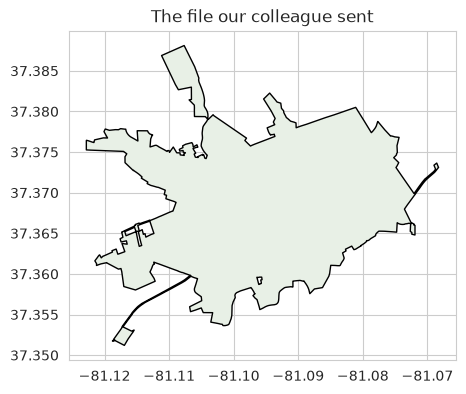

In [2]:
mystery = gpd.read_file("data/mystery_boundary.geojson")

ax = mystery.plot(figsize=(5, 5), color="#e8f0e6", edgecolor="black")
ax.set_title("The file our colleague sent")

We can see a closed shape with a ragged edge, the kind of outline a municipality really does have. Nothing about it looks wrong. It loaded without an error, it drew without a warning, and if you had asked for a boundary and received this, you would very likely get on with your day.

That is the entire problem. **A file that opens is not a file that is right, and a map that renders is not a map that is right.** Rendering is the computer's job. Being right is yours.

So let us not look at it. Let us ask it three questions.

## Check one, what are the units

Every spatial dataset carries a **coordinate reference system**, its CRS, which is the agreement about what its two numbers mean. Without it a pair like `(-74.65, 40.35)` is just two numbers; with it, they are a place.

The most important thing a CRS tells you is the **units**. Some are measured in degrees of angle around the planet, others in metres or feet on the ground. Mixing them up is the single most common way to produce a confident, plausible, wrong answer, and we will do exactly that on purpose in 01-04.

A GeoDataFrame reports its own CRS through `.crs`. Note that there are no parentheses, because this is a property of the table rather than something it does:

In [3]:
print(mystery.crs)

EPSG:4326


We can see `EPSG:4326`, with the axis information reading degrees.

`EPSG:4326` is a number from a public catalogue of coordinate systems, and it is the one your phone uses: plain longitude and latitude in degrees. So this file is measured in degrees, which is entirely normal and tells us nothing suspicious yet. It does tell us that any distance or area we compute from it directly would come out in degrees, which is not a unit of length.

Note that we wrapped this in `print`. A notebook shows only the value of the *last* line of a cell, so when we want to see several things we have to say so. That is the small bite we warned about in 01-02.

## Check two, where on Earth is it

The second question is the most useful of the three and takes one line. Every GeoDataFrame can report the rectangle that encloses everything in it, through `.total_bounds`.

It hands back four numbers in this order: minimum x, minimum y, maximum x, maximum y. In a system measured in degrees, x is longitude and y is latitude, so those four numbers are west edge, south edge, east edge, north edge:

In [4]:
print(mystery.total_bounds)

[-81.12282   37.3512   -81.068259  37.38811 ]


We can see roughly -81.12, 37.35, -81.07, 37.39.

Now compare that with the Princeton we drew in 01-02, whose axes ran from about -74.72 to -74.62 in longitude and 40.30 to 40.39 in latitude.

The longitude is off by about six and a half degrees and the latitude by about three. A degree of latitude is close to 111 kilometres everywhere on Earth, so this file sits roughly three hundred kilometres south of Princeton, New Jersey, and a good deal further west. Whatever it is, it is not our town.

This is why check two is the one to run first when you are in a hurry. It is a single line, it needs no reprojection, and it catches the largest and most embarrassing class of error: the right shape of thing, in the wrong part of the world.

## Check three, how big is it

The third question is the size. Princeton is a town you can cycle across in twenty minutes, so anything the size of a county or the size of a car park is wrong.

Here we hit the units problem head on. Our data is in degrees, and area in degrees is meaningless, because a degree of longitude is a different distance in Princeton than it is in Iceland. To get an area we must first re-express the data in a system measured in metres.

That is what `to_crs` does. It does not move the data, it re-expresses the same places in a different set of numbers. For New Jersey the right choice is `EPSG:26918`, a system measured in metres and designed for this strip of the world, and 01-06 explains where that number comes from.

Then `.geometry.area` gives an area in square metres, and dividing by a million turns square metres into square kilometres:

In [5]:
area_km2 = mystery.to_crs("EPSG:26918").geometry.area.iloc[0] / 1e6
print(f"{area_km2:.2f} square kilometres")

7.96 square kilometres


We can see about 7.96 square kilometres.

To know whether that is wrong we need something to compare it against, and rather than trusting our memory we can read the reference values that ship beside the data:

In [6]:
reference = json.load(open("data/ground_truth.json"))

print("Princeton, New Jersey")
print(f"  area          {reference['boundary']['area_km2']} square kilometres")
print(f"  bounds        {reference['boundary']['total_bounds']}")
print(f"  buildings     {reference['counts']['buildings']}")
print(f"  places to eat {reference['counts']['food']}")

Princeton, New Jersey
  area          47.66 square kilometres
  bounds        [-74.7221, 40.3049, -74.6175, 40.3911]
  buildings     7893
  places to eat 92


The real Princeton is 47.66 square kilometres. Our mystery file is 7.96, i.e. about six times smaller.

Note what we did there, because it is a habit rather than a trick. The reference numbers were not typed into this notebook from memory; they were read out of a file that is generated by the same pipeline that produced the data. A number you type is a number that can quietly go stale. A number you read stays true.

Three checks, three answers: it is in degrees, it sits three hundred kilometres away, and it is six times too small. We do not need to look at the picture at all.

## So what was it

It is Princeton, West Virginia, a town of about six thousand people in Mercer County, roughly five hundred kilometres from here.

That is why the file looked so convincing. It really is a municipal boundary, it really is called Princeton, and if you had searched a data portal for "Princeton" without looking at the state, this is very plausibly what you would have got. Nothing about it is malformed. It is simply the wrong one.

Note the shape of the trap. It was not corrupt data, and no software failed. Every piece of the system worked exactly as designed, and the error was entirely in what we assumed. Those are the errors that survive all the way into a report.

Let us look at the two of them together, drawn at the same scale:

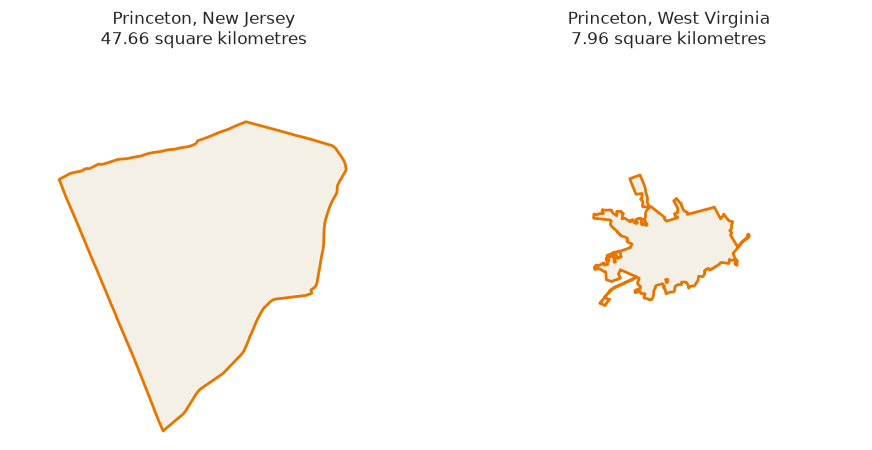

In [7]:
nj = gpd.read_file("data/princeton_boundary.geojson").to_crs("EPSG:26918")
wv = mystery.to_crs("EPSG:26918")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for axis, layer, title in zip(axes, [nj, wv], ["Princeton, New Jersey", "Princeton, West Virginia"]):
    centre = layer.geometry.iloc[0].centroid
    layer.plot(ax=axis, color="#f5f0e6", edgecolor="#e77500", linewidth=2)
    axis.set_xlim(centre.x - 6000, centre.x + 6000)
    axis.set_ylim(centre.y - 6000, centre.y + 6000)
    axis.set_title(f"{title}\n{layer.geometry.area.iloc[0] / 1e6:.2f} square kilometres")
    axis.set_axis_off()

Both panels cover exactly the same twelve kilometres of ground, so the comparison is honest. Our Princeton fills its frame; the other sits in the middle of its own like a village, which is roughly what it is.

Note that this picture is only possible *after* the reprojection. Had we drawn them in degrees, the two frames would cover different amounts of ground, because a degree of longitude at latitude 37 is wider than at latitude 40, and the smaller town would have looked deceptively larger. Even the act of comparing two places fairly needs a coordinate system measured in metres.

## The trap inside check three

The third check has a trap of its own, and it is worth meeting now because it has already caught a professional.

New Jersey keeps its official records in another coordinate system, `EPSG:3424`, which is measured in **feet** rather than metres. Everything about our third check still works in it: `to_crs` succeeds, `.area` returns a number, and nothing warns you. But the number is now in square feet, and if we divide by a million out of habit we get something that looks like square kilometres and is not.

Let us do exactly that to our real, correct Princeton boundary:

In [8]:
print(nj.to_crs("EPSG:3424").geometry.area.iloc[0] / 1e6)

513.2914583485001


We can see about 513.

That is our own correct boundary, our own correct code, and an answer that is wrong by a factor of eleven. Nothing raised, nothing warned, and the number has a confident decimal tail.

This is not hypothetical. While this precept was being prepared, an AI coding agent was asked to make a map of Princeton, and it reported the town's area as 514 square kilometres by making precisely this mistake in precisely this coordinate system. It caught the error itself only because it happened to compute the area four different ways and noticed one disagreed.

So the defence is not cleverness, it is a sense of scale. Princeton is a town you can walk across in an afternoon. Nobody who has done that believes 513 square kilometres, and nobody who has done that believes 7.96 either. Keep one real number in your head for anything you work on, and the wrong ones announce themselves.

## Check your understanding

1. Of the three checks, which one would have caught the West Virginia file fastest, and why?
2. `mystery.total_bounds` gave a latitude near 37.35, while Princeton sits near 40.35. Roughly how many kilometres apart is that?
3. Check three needed `to_crs` before `.area`. Why can we not simply call `.area` on the file as it arrives?
4. Both files drew a believable shape. Name one thing you could have noticed by eye, and one thing you could not possibly have noticed by eye.

## Where we are, and what is next

You now have a habit that most people who work with spatial data do not have. Three lines, in this order:

- `.crs`, i.e. what are the units
- `.total_bounds`, i.e. where on Earth is this
- an area in a metric system, i.e. how big is it

Run them on anything anybody hands you, including yourself, and especially including anything produced by a machine.

In 01-04 we put that habit to work on a real question, we get it wrong twice on purpose, and then we hand the same question to an AI agent and grade its answer against our own.

## Further resources

Nothing in this course requires anything below.

**Coordinate systems.** Any EPSG number can be looked up at https://epsg.io, which is the fastest way to find out what a colleague's file is actually in. Compare https://epsg.io/4326 with https://epsg.io/26918 and note that one lists its units as degrees and the other as metres. The PROJ documentation explains what actually happens during a `to_crs`: https://proj.org/en/stable/usage/projections.html.

**The data.** The impostor is a United States Census Bureau place polygon, from the TIGER/Line collection, which is public domain: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html. The real boundary is a public record from NJGIN Open Data: https://njogis-newjersey.opendata.arcgis.com.